# 05 - Scaling: state counts, solver choice, and the speedup mechanism

The paper's headline speedups are measured on **IEEE benchmark networks** whose
case files are *not redistributed* with this release. This notebook is honest
about that: it reproduces the speedup **mechanism** from circuits that ship in
the package, and points you at the command + external data needed for the
published IEEE figures.

What you can run here, offline:

1. A computational benchmark over every bundled example (state counts, the
   auto-selected solver, timing).
2. The IDP-vs-TD speedup trend on the series RLC - the same mechanism that drives
   the IEEE numbers, on a circuit that ships with the package.

In [1]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt
import dpspice

print("Benchmark over bundled examples")
print("-" * 60)
for name in ["rlc.sp", "rectifier_halfwave.sp", "rectifier_rc.sp"]:
    r = dpspice.load(dpspice.example_text(name)).run(with_waveforms=False)
    print("%-22s solver=%-4s states=%d K=%s  solve=%.1f ms" % (
        name, r.solver, r.states, r.K, r.solve_time * 1e3))

Benchmark over bundled examples
------------------------------------------------------------


rlc.sp                 solver=idp  states=5 K=None  solve=367.2 ms
rectifier_halfwave.sp  solver=hb   states=3 K=20  solve=35.8 ms
rectifier_rc.sp        solver=hb   states=3 K=20  solve=27.2 ms


## The speedup mechanism: IDP cost is flat, TD cost scales with duration

We sweep the simulated window on the series RLC and time IDP vs full TD. The
IDP/TD speedup grows roughly tenfold per decade of duration - exactly the
mechanism behind the paper's IEEE-network envelope. The absolute factors on a
big network depend on that network's size and the simulated horizon; the
*trend* is what generalises.

In [2]:
F = 580e3 / (2 * np.pi)
def rlc(n):
    return (f"V1 in 0 SINE(0 1 {F:.6g})\nR1 in n2 3.0\nL1 n2 out 100.04u\n"
            f"C1 out 0 30.07n\nR2 out 0 2k\n.tran 0 {n / F:.6g}\n.end\n")

windows, speedups = [12, 50, 200, 800, 3200], []
for n in windows:
    nl = rlc(n)
    t0 = time.perf_counter(); dpspice.load(nl).run(mode="idp"); idp = time.perf_counter() - t0
    t0 = time.perf_counter(); dpspice.load(nl).run(mode="td");  td  = time.perf_counter() - t0
    speedups.append(td / max(idp, 1e-12))
    print("%5d cycles -> speedup %7.1fx" % (n, speedups[-1]))

   12 cycles -> speedup     0.7x


   50 cycles -> speedup     1.8x


  200 cycles -> speedup     7.6x


  800 cycles -> speedup    30.0x


 3200 cycles -> speedup   109.3x


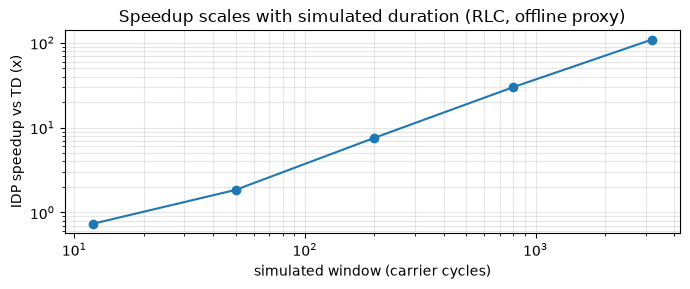

In [3]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.loglog(windows, speedups, "o-")
ax.set_xlabel("simulated window (carrier cycles)")
ax.set_ylabel("IDP speedup vs TD (x)")
ax.set_title("Speedup scales with simulated duration (RLC, offline proxy)")
ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## Reproducing the published IEEE numbers

The IEEE-network timing tables need case files this repository does not
redistribute. To regenerate them, bring the IEEE case files and run the
validation suite; `dpspice reproduce` lists the external-data artifacts and what
they require:

```bash
dpspice reproduce            # lists reproducible vs needs-external-data artifacts
dpspice suite --quick        # steady-state smoke test across circuit families
```

See `REPRODUCIBILITY.md` for the full artifact-to-command map and the recorded
paper-vs-code scope notes.